* `import numpy as np`:
    * **Use:** For numerical operations, especially with arrays (think of grids of data like temperature or salinity).
    * `np` is the standard shorthand.

* `import xarray as xr`:
    * **Use:** For handling labeled multi-dimensional datasets (e.g., data with latitude, longitude, depth, and time coordinates). This is crucial for common oceanographic data formats like NetCDF.
    * `xr` is the standard shorthand.

* `import matplotlib.pyplot as plt`:
    * **Use:** Our primary library for creating all kinds of plots and visualizations (maps, vertical sections, time series, etc.).
    * `plt` is the standard shorthand.

* `import matplotlib.colors as colors`:
    * **Use:** Provides tools for controlling colors in our plots. This is very important for representing data values visually, for example, using different colors for different temperatures on a map.

* `import matplotlib.patches as mpatches`:
    * **Use:** Allows us to add various shapes (like rectangles, circles, or polygons) to our plots. This can be useful for highlighting specific regions on a map or creating custom legend entries.

* `import warnings`
    `warnings.filterwarnings('ignore')`:
    * **Use:** This line tells Python to suppress warning messages that might pop up when the code runs.
    * **Note:** For these exercises, it helps keep the output clean. However, in your own research or more complex projects, it's usually a good idea to look at warnings as they can point to potential issues or outdated code.

In [ ]:
# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches

# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

* `from google.colab import drive`:
    * **Use:** This line imports the `drive` module from the `google.colab` library. This module specifically contains the tools needed to interact with Google Drive from within your Colab notebook.

* `drive.mount('/content/drive/')`:
    * **Use:** This is the command that actually establishes the connection (or "mounts") your Google Drive to the Colab environment.
    * `/content/drive/`: This is the specific path within the Colab virtual machine where your Google Drive's contents will become accessible. Think of it as creating a doorway to your Drive.
    * **Important:** When you run this command for the first time in a notebook, Colab will ask for your **authorization**. It will provide a link to a Google authentication page. You'll need to click the link, sign in to your Google account, copy the authorization code provided, and paste it into the input box that appears in Colab. This step ensures that only you can grant access to your Drive files.

* `!ls "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab"`:
    * **Use:** This command lists the files and folders inside the specified directory in your Google Drive.
    * `!ls`: The exclamation mark (`!`) at the beginning tells Colab to run this command as a **shell command** (like you would in a Linux or macOS terminal) rather than as Python code. `ls` is the standard command for listing directory contents.
    * `"/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab"`: This is the **path** to the folder whose contents you want to see.
        * `/content/drive/My Drive/`: This is the standard starting point for your mounted Google Drive.
        * `Course Lectures/OCN 2102 Physical Oceanography Lab`: This part needs to exactly match the folder structure and name within your "My Drive". **Paths are case-sensitive!**
    * **Purpose:** This helps you verify that the Drive is mounted correctly and that you can "see" the files you expect to be in that course folder, like datasets we might use later.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

!ls "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab"

Mounted at /content/drive/
 Lab-01_Intro_to_data.ipynb
 Lab-02_Python_Fundamentals.ipynb
 Lab-03_Functions_Classes.ipynb
 OCN-2102_Lab_Final.docx
 OCN-2102_Lab_Final.pdf
'OCN-2102 Lab Viva.xlsx'
 OCN-2102_phys_BoB-monthly_2015-2022.nc
 OCN-2102_phys_Hudson_Bay-monthly_2015-2022.nc
'OCN-2102-Physical Oceanography Lab.docx'
'OCN-2102-Physical Oceanography Lab.pdf'


This cell prepares to load our oceanographic data. First, it defines the location (path) of our data file within your Google Drive, and then it uses the **xarray** library to open that file. 💾

* `# Define the paths to the NetCDF filesHadISST_Sea_Ice_1870-2023.nc`:
    * **Use:** This is a **comment**. Comments in Python start with a `#` and are ignored by the Python interpreter. They are notes for humans reading the code.
    * **Note:** It looks like there's a filename at the end of this comment (`HadISST_Sea_Ice_1870-2023.nc`) that isn't actually being used in the active code below it. The active code uses `OCN-2102_phys_BoB-monthly_2015-2022.nc`. This is a good reminder to keep comments updated if your code changes!

* `path = "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab/OCN-2102_phys_BoB-monthly_2015-2022.nc"`:
    * **Use:** This line creates a **variable** named `path`. A variable is like a label or a container for a piece of information.
    * **`"/content/drive/..."`**: This is a **string** (text) that holds the full path to our dataset file.
        * It starts with `/content/drive/My Drive/`, which is where your Google Drive is mounted (as we saw in the previous cell).
        * It then navigates through your specified folder structure: `Course Lectures/OCN 2102 Physical Oceanography Lab/`.
        * Finally, it includes the actual filename: `OCN-2102_phys_BoB-monthly_2015-2022.nc`.
    * **Important:** This path must exactly match where your file is stored in Google Drive, including capitalization and the `.nc` extension (which signifies a NetCDF file, a common format for climate and oceanographic data).

* `ds = xr.open_dataset(path)`:
    * **Use:** This is the command that actually opens the NetCDF data file.
    * `xr.open_dataset()`: This is a function from the **xarray** library (which we imported earlier as `xr`). It's designed to read data and metadata from NetCDF files (and other compatible formats) into a structure that's easy to work with.
    * `(path)`: We provide the `path` variable (which holds the string location of our file) to the function so it knows which file to open.
    * `ds = `: The result of opening the file (the dataset itself) is stored in a new variable called `ds` (short for "dataset").
    * **What is `ds`?**: The variable `ds` now holds an **xarray Dataset object**. Think of this as a smart container that holds not only the data values (like temperature, salinity) but also the labels for its dimensions (like latitude, longitude, depth, time), coordinates, and any other metadata included in the file. This makes accessing, analyzing, and plotting the data much more intuitive.

In [ ]:
# Define the paths to the NetCDF files
path = "/content/drive/My Drive/Course Lectures/OCN 2102 Physical Oceanography Lab/OCN-2102_phys_BoB-monthly_2015-2022.nc"

# Open the files and store them in a Python variable
ds = xr.open_dataset(path)

This cell simply contains the variable `ds` on its own.

* `ds`:
    * **Use:** In Google Colab (and Jupyter notebooks), if the last line of a code cell is just a variable name (or an expression that returns a value), Colab will automatically display a representation of that variable or value as output below the cell.
       * **Why this is useful:** Running this cell provides a quick and interactive way to **inspect the structure and contents of your dataset** right after loading it. It helps you verify that the file loaded correctly and allows you to see what variables, dimensions, and metadata are available before you start any analysis or plotting. It's a fundamental first step in data exploration.

In [ ]:
ds

<xarray.Dataset> Size: 797MB
Dimensions:    (time: 216, depth: 26, latitude: 80, longitude: 88)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2005-01-01 2005-02-01 ... 2022-12-01
  * depth      (depth) float32 104B -0.0 5.0 10.0 15.0 ... 250.0 275.0 300.0
  * latitude   (latitude) float32 320B 5.125 5.375 5.625 ... 24.38 24.62 24.88
  * longitude  (longitude) float32 352B 78.12 78.38 78.62 ... 99.38 99.62 99.88
Data variables:
    so         (time, depth, latitude, longitude) float32 158MB ...
    to         (time, depth, latitude, longitude) float32 158MB ...
    ugo        (time, depth, latitude, longitude) float32 158MB ...
    vgo        (time, depth, latitude, longitude) float32 158MB ...
    zo         (time, depth, latitude, longitude) float32 158MB ...
    mlotst     (time, latitude, longitude) float32 6MB ...
Attributes:
    Conventions:       CF-1.11
    title:             ARMOR3D REP - TSHUVMld Global Ocean Observation-based ...
    institution:       CLS
    history:           1993-01-15 12:00:00 ARMOR3D REP - TSHUV Global Ocean O...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  MULTIOBS_GLO_PHY_TSUV_3D_MYNRT_015_012
    subset:datasetId:  dataset-armor-3d-rep-monthly_202012
    subset:date:       2025-04-14T08:35:06.363Z

This cell demonstrates a common oceanographic task: extracting and plotting a vertical profile of a variable (in this case, salinity) at a specific geographic location and time, down to a certain depth.

* `# Define the actual date you want to use`
    `time = "2022-12-01"  # use actual date instead of time index`:
    * **Use:** We're defining a variable `time` and assigning it a specific date as a string.
    * Xarray is smart enough to often interpret date strings like "YYYY-MM-DD" correctly if your time coordinate in the dataset is datetime-like. This is more intuitive than finding a numerical time index.

* `# Example: select a specific latitude and longitude index`
    `lat_idx = 40  # around middle latitude`
    `lon_idx = 40  # around middle longitude`:
    * **Use:** We're defining variables `lat_idx` and `lon_idx` to specify the *integer index* for the latitude and longitude we're interested in.
    * **Note:** Using `.isel()` (index selection) means we're picking the 40th latitude and 40th longitude point from our data grid, *not* necessarily 40 degrees latitude or 40 degrees longitude. The comment "around middle" suggests these indices were chosen to be somewhere central in the dataset's spatial domain.

* `# Select the salinity profile at that date and location`
    `salinity_profile = ds['so'].sel(time=time).isel(latitude=lat_idx, longitude=lon_idx)`:
    * **Use:** This is the core data extraction step using xarray's powerful selection methods. Let's break it down:
        * `ds['so']`: We first access the salinity data variable from our dataset `ds`. We assume 'so' is the variable name for salinity (a common convention). This returns an xarray DataArray.
        * `.sel(time=time)`: On this salinity DataArray, we use the `.sel()` method for **label-based selection**. We're selecting data where the `time` coordinate matches the `time` variable we defined (i.e., "2022-12-01").
        * `.isel(latitude=lat_idx, longitude=lon_idx)`: After selecting by time, we chain the `.isel()` method for **integer index-based selection**. This selects the data at the 40th latitude point and the 40th longitude point *from the result of the time selection*.
    * The resulting 1D array (salinity values at different depths for that specific time and location) is stored in the `salinity_profile` variable.

* `salinity_profile = salinity_profile.sel(depth=slice(0, 150))`:
    * **Use:** We further refine our `salinity_profile` to only include depths from the surface down to 150 meters.
    * `.sel(depth=slice(0, 150))`: We use `.sel()` again, this time on the `depth` coordinate. `slice(0, 150)` tells xarray to select all depth values that fall within the range of 0 to 150 (inclusive, if these are actual coordinate values). This is useful for focusing on the upper ocean.

* `# Plot`: This section uses `matplotlib.pyplot` (which we imported as `plt`) to create the plot.

* `plt.figure(figsize=(6, 8))`:
    * **Use:** Creates a new figure for our plot and sets its size to be 6 inches wide and 8 inches tall. This helps make the plot readable.

* `plt.plot(salinity_profile, salinity_profile['depth'])`:
    * **Use:** This is the main plotting command.
        * The first argument (`salinity_profile`) provides the values for the x-axis (salinity).
        * The second argument (`salinity_profile['depth']`) provides the values for the y-axis (depth, accessed as a coordinate from the `salinity_profile` DataArray).

* `plt.gca().invert_yaxis()`:
    * **Use:** `gca()` gets the current axes of the plot. `.invert_yaxis()` reverses the y-axis.
    * **Crucial for Oceanography:** In oceanography, depth is almost always plotted with 0 at the top and increasing downwards, simulating how we experience depth in the ocean. Standard plots have the y-axis increasing upwards, so we need to invert it.

* `plt.xlabel('Salinity (psu)')`:
    * **Use:** Sets the label for the x-axis. 'psu' (Practical Salinity Units) is a common unit for salinity.

* `plt.ylabel('Depth (m)')`:
    * **Use:** Sets the label for the y-axis, indicating depth in meters.

* `plt.title(f'Vertical Salinity Profile (0–150 m)\nDate: {time}')`:
    * **Use:** Sets the title of the plot.
    * `f'...'`: This is an "f-string" in Python. It allows us to embed variables directly into the string. Here, `{time}` will be replaced by the value of our `time` variable ("2022-12-01").
    * `\n`: This creates a newline character, so the date appears on a separate line in the title.

* `plt.grid(True)`:
    * **Use:** Adds a grid to the plot, which can make it easier to read values.

* `plt.show()`:
    * **Use:** Displays the generated plot in the output of the Colab cell.

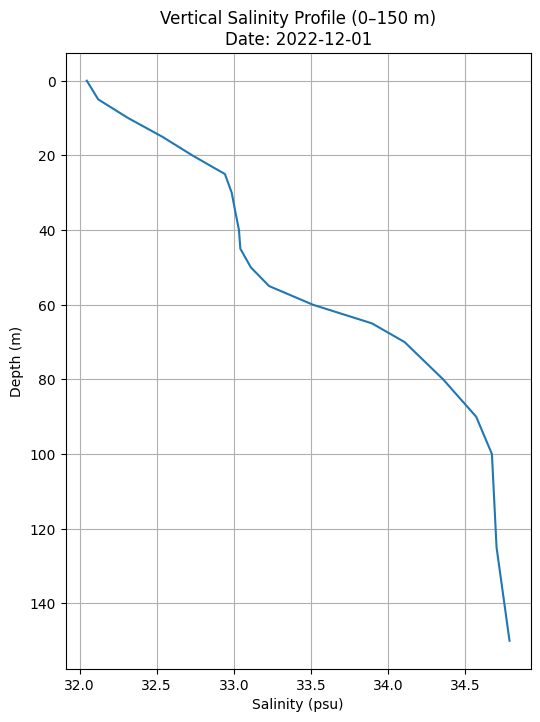

In [ ]:
# Define the actual date you want to use
time = "2022-12-01"  # use actual date instead of time index

# Example: select a specific latitude and longitude index
lat_idx = 40  # around middle latitude
lon_idx = 40  # around middle longitude

# Select the salinity profile at that date and location
salinity_profile = ds['so'].sel(time=time).isel(latitude=lat_idx, longitude=lon_idx)
salinity_profile = salinity_profile.sel(depth=slice(0, 150))

# Plot
plt.figure(figsize=(6, 8))
plt.plot(salinity_profile, salinity_profile['depth'])
plt.gca().invert_yaxis()
plt.xlabel('Salinity (psu)')
plt.ylabel('Depth (m)')
plt.title(f'Vertical Salinity Profile (0–150 m)\nDate: {time}')
plt.grid(True)
plt.show()


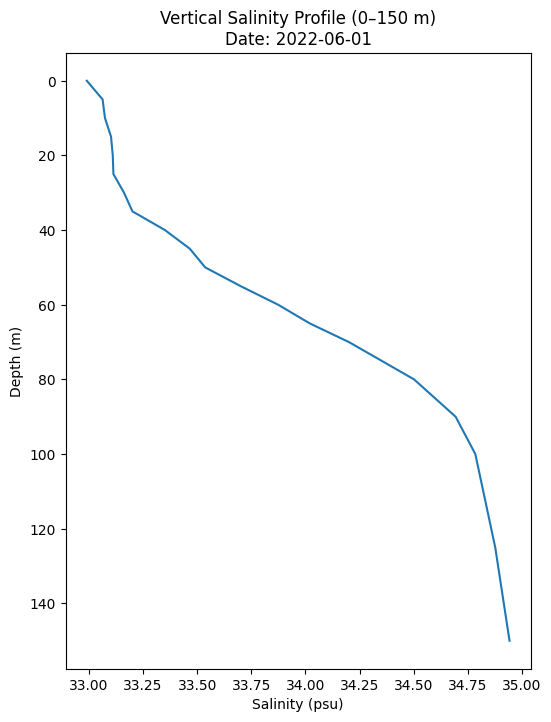

In [ ]:
# Define the actual date you want to use
time = "2022-06-01"  # use actual date

# Example: select a specific latitude and longitude index
lat_idx = 40  # around middle latitude
lon_idx = 40  # around middle longitude

# Select the salinity profile at that date and location
salinity_profile = ds['so'].sel(time=time).isel(latitude=lat_idx, longitude=lon_idx)
salinity_profile = salinity_profile.sel(depth=slice(0, 150))

# Plot
plt.figure(figsize=(6, 8))
plt.plot(salinity_profile, salinity_profile['depth'])
plt.gca().invert_yaxis()
plt.xlabel('Salinity (psu)')
plt.ylabel('Depth (m)')
plt.title(f'Vertical Salinity Profile (0–150 m)\nDate: {time}')
plt.show()


This cell shows a more advanced data processing step: selecting a 3D chunk of data over a specific geographic area and depth range, then calculating an area-averaged vertical profile (in this case, for temperature), and finally plotting it.

* `# Define the actual date you want to use`
    `time = "2022-06-01"  # actual date`:
    * **Use:** As before, this sets the `time` variable to "2022-06-01". The comment `# actual date` simply reiterates that we're using a specific date for our analysis.

* `# Select region and depth range`
    `temperature_area = ds['to'].sel(`
    `    time=time,`
    `    latitude=slice(10, 20),   # Latitude 10N to 20N`
    `    longitude=slice(80, 90),  # Longitude 80E to 90E`
    `    depth=slice(0, 100)       # Depth from surface to 100 meters`
    `)`:
    * **Use:** This is a powerful data selection using xarray's `.sel()` method to extract a "chunk" or "subset" of the temperature data.
        * `ds['to']`: We're accessing the data variable named 'to' from our dataset `ds`. This is likely to be **temperature** (often 'theta-o' in oceanographic datasets).
        * `time=time`: Selects data for the date specified in our `time` variable.
        * `latitude=slice(10, 20)`: This selects all data points where the latitude coordinate values fall **between 10 and 20** (inclusive, if these exact coordinate values exist). This defines a latitudinal band (e.g., 10°N to 20°N).
        * `longitude=slice(80, 90)`: Similarly, this selects data where the longitude coordinate values fall **between 80 and 90** (e.g., 80°E to 90°E).
        * `depth=slice(0, 100)`: This selects data for depth levels **from the surface (0 meters) down to 100 meters**.
    * The result, `temperature_area`, is an xarray DataArray containing temperature values for the specified time, latitude range, longitude range, and depth range.

* `# Average over latitude and longitude`
    `temperature_mean_profile = temperature_area.mean(dim=['latitude', 'longitude'])`:
    * **Use:** This line calculates the average temperature profile over the selected geographic area.
        * `.mean(dim=['latitude', 'longitude'])`: This method is applied to our `temperature_area` DataArray. It computes the **mean (average)** of the temperature values along the specified dimensions: `latitude` and `longitude`.
        * The result, `temperature_mean_profile`, is a 1D DataArray where temperature varies only with `depth`. Each temperature value in this profile represents the average temperature across the entire 10°N–20°N, 80°E–90°E region at that specific depth level and time.
        * **Why do this?** Area-averaging helps to get a more general or representative profile for a region, smoothing out small-scale local variations.

* `# Plot`: This section uses Matplotlib to visualize the `temperature_mean_profile`.

* `plt.figure(figsize=(6, 8))`: Sets up the plot figure, as explained before.

* `plt.plot(temperature_mean_profile, temperature_mean_profile['depth'])`:
    * **Use:** Plots the `temperature_mean_profile` (x-axis) against its corresponding `depth` coordinates (y-axis).

* `plt.gca().invert_yaxis()`: Inverts the y-axis (depth), crucial for oceanographic profiles.

* `plt.xlim(23, 31)`:
    * **Use:** This new command sets the limits for the x-axis (temperature). The plot will only show temperatures ranging from 23 to 31 degrees. This can be useful to "zoom in" on the relevant range of temperature values and improve the visual clarity of the profile's structure.

* `plt.xlabel('Temperature ($^\circ$C)')`:
    * **Use:** Sets the x-axis label.
    * **Note the LaTeX:** `($^\circ$C)` is used to display the degree Celsius symbol (°C) correctly on the plot. Matplotlib can render LaTeX for nice mathematical and scientific notation.

* `plt.ylabel('Depth (m)')`: Sets the y-axis label.

* `plt.title(f'Area-averaged Temperature Profile\n(10°N–20°N, 80°E–90°E) on {time}')`:
    * **Use:** Sets the title for the plot. The f-string dynamically inserts the date.
    * The title now clearly states that this is an "Area-averaged" profile and specifies the latitude/longitude bounds of the averaging region.

* `plt.show()`: Displays the plot.

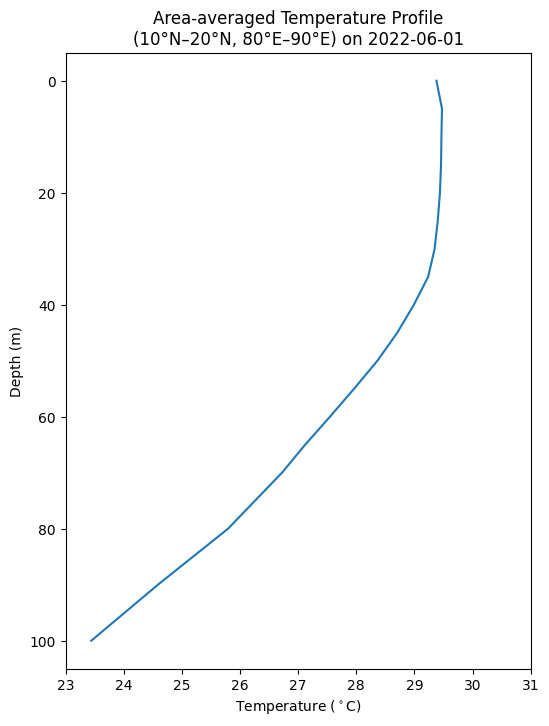

In [ ]:
# Define the actual date you want to use
time = "2022-06-01"  # actual date

# Select region and depth range
temperature_area = ds['to'].sel(
    time=time,
    latitude=slice(10, 20),    # Latitude 10N to 20N
    longitude=slice(80, 90),   # Longitude 80E to 90E
    depth=slice(0, 100)        # Depth from surface to 100 meters
)

# Average over latitude and longitude
temperature_mean_profile = temperature_area.mean(dim=['latitude', 'longitude'])

# Plot
plt.figure(figsize=(6, 8))
plt.plot(temperature_mean_profile, temperature_mean_profile['depth'])
plt.gca().invert_yaxis()
plt.xlim(23, 31)
plt.xlabel('Temperature ($^\circ$C)')
plt.ylabel('Depth (m)')
plt.title(f'Area-averaged Temperature Profile\n(10°N–20°N, 80°E–90°E) on {time}')
plt.show()

This cell demonstrates a more sophisticated way to visualize a vertical profile by splitting it into two "viewports" or subplots. This allows us to examine different depth ranges of the same profile with potentially different zoom levels or emphasis, all within a single figure. Here, it's used to show an area-averaged salinity profile from the surface down to 200 meters, split into 0-100m and 100-200m sections.

* `# Define the actual date you want to use`
    `time = "2022-06-01"  # actual date`:
    * This sets our analysis time, as in previous cells.

* `# Select region and depth range`
    `salinity_area = ds['so'].sel(`
    `    time=time,`
    `    latitude=slice(10, 20),`
    `    longitude=slice(80, 90),`
    `    depth=slice(0, 200)  # Note: depth now goes to 200 meters`
    `)`:
    * Similar to the previous temperature example, this selects a 3D chunk of **salinity** data (`ds['so']`) for the specified time, latitude range (10-20), and longitude range (80-90).
    * **Key difference:** The `depth` is now selected using `slice(0, 200)`, so we are extracting data from the surface down to 200 meters.

* `# Average horizontally`
    `salinity_mean_profile = salinity_area.mean(dim=['latitude', 'longitude'])`:
    * Just like with temperature before, this calculates the average salinity profile over the selected geographic area (10-20 Lat, 80-90 Lon), resulting in a 1D profile of salinity varying with depth (down to 200m).

* `# Create subplots`
    `fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)`:
    * **Use:** This is the command to create a figure containing multiple subplots.
        * `plt.subplots(2, 1)`: Creates a grid of subplots with 2 rows and 1 column.
        * `figsize=(6, 10)`: Sets the overall size of the entire figure.
        * `sharex=True`: This is an important argument! It means that both subplots (`ax1` and `ax2`) will share the same x-axis. Zooming or panning on one x-axis will affect the other, and x-axis labels/ticks are typically only shown on the bottom-most subplot to avoid redundancy.
        * `fig, (ax1, ax2)`: This "unpacks" the output of `plt.subplots()`.
            * `fig`: Is the entire figure object (the container for all plots).
            * `ax1`: Is the Axes object for the first subplot (the top one).
            * `ax2`: Is the Axes object for the second subplot (the bottom one). We'll use `ax1` and `ax2` to draw on each specific subplot.

* `# First viewport: 0–100 meters`
    * `ax1.plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')`:
        * Instead of `plt.plot()`, we now use `ax1.plot()` to draw the salinity profile specifically on the *first subplot*. We're plotting the *entire* `salinity_mean_profile` (which goes to 200m).
    * `ax1.set_ylim(100, 0)`:
        * This is key: we set the y-axis (depth) limits for `ax1` to range from 100m to 0m (inverted, so 0m is at the top). Even though the plotted data goes deeper, this effectively "zooms" the top subplot to show only the 0-100m portion.
    * `ax1.set_ylabel('Depth (m)')`: Sets the y-label for the first subplot.
    * `ax1.set_title(f'Salinity Profile (0–200 m) on {time}')`: Sets the main title for the figure, placed above the first subplot.

* `# Second viewport: 100–200 meters`
    * `ax2.plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')`:
        * We plot the *same entire* `salinity_mean_profile` on the *second subplot* (`ax2`).
    * `ax2.set_ylim(200, 100)`:
        * For `ax2`, we set the y-axis limits to range from 200m to 100m (inverted). This makes the second subplot display the deeper portion of the profile, from 100m down to 200m.
    * `ax2.set_xlabel('Salinity (psu)')`: Sets the x-label (Salinity). Because `sharex=True` was used, this label will appear at the bottom of the entire figure.
    * `ax2.set_ylabel('Depth (m)')`: Sets the y-label for the second subplot.

* `# Optionally control salinity range`
    `ax1.set_xlim(32, 37)`
    `ax2.set_xlim(32, 37)`:
    * These lines set the x-axis (salinity) limits for both subplots to be the same (32 to 37 psu). This ensures that a given salinity value aligns vertically across both subplots, making visual comparison easier. `sharex=True` would typically link the axes ranges if you pan/zoom interactively, but setting explicit limits ensures they start the same.

* `plt.tight_layout()`:
    * **Use:** This command automatically adjusts subplot parameters to give a "tight" layout, often preventing labels or titles from overlapping between subplots. It's good practice to use when working with multiple subplots.

* `plt.show()`: Displays the complete figure with both subplots.

This technique allows you to present a detailed view of a profile that might have different features of interest at different depth ranges, without making one very long plot or losing resolution.

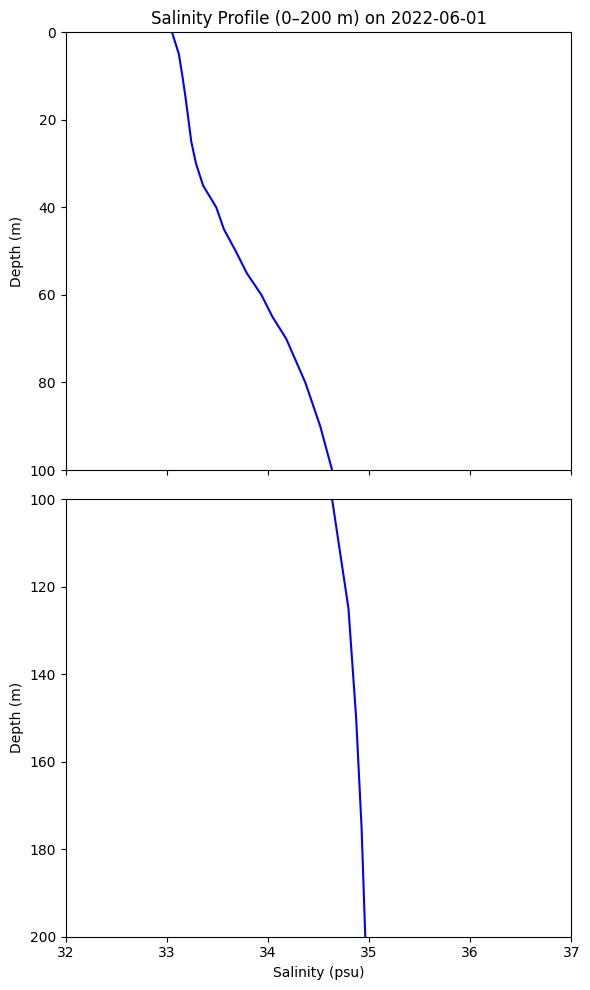

In [ ]:
# Define the actual date you want to use
time = "2022-06-01"  # actual date

# Select region and depth range
salinity_area = ds['so'].sel(
    time=time,
    latitude=slice(10, 20),
    longitude=slice(80, 90),
    depth=slice(0, 200)
)

# Average horizontally
salinity_mean_profile = salinity_area.mean(dim=['latitude', 'longitude'])

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)

# First viewport: 0–100 meters
ax1.plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')
ax1.set_ylim(100, 0)  # shallow depths at top
ax1.set_ylabel('Depth (m)')
ax1.set_title(f'Salinity Profile (0–200 m) on {time}')

# Second viewport: 100–200 meters
ax2.plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')
ax2.set_ylim(200, 100)
ax2.set_xlabel('Salinity (psu)')
ax2.set_ylabel('Depth (m)')

# Optionally control salinity range
ax1.set_xlim(32, 37)
ax2.set_xlim(32, 37)

plt.tight_layout()
plt.show()


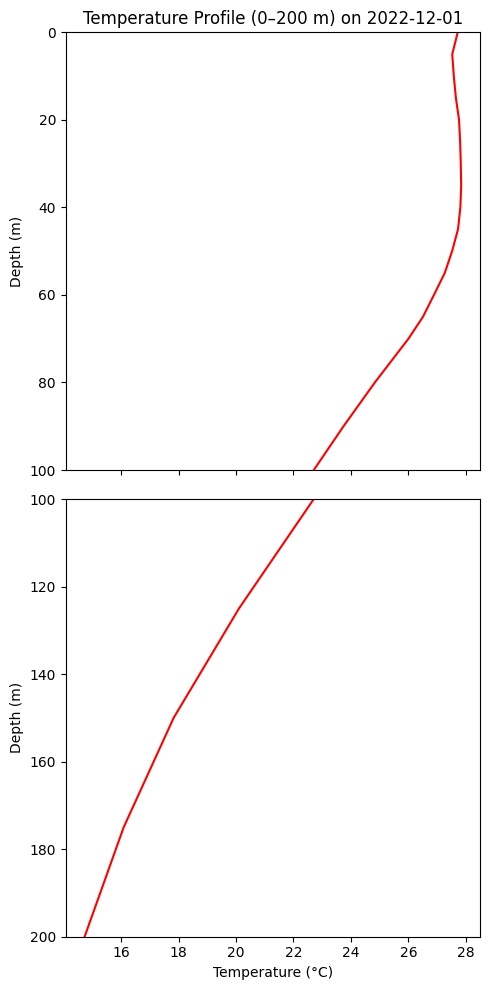

In [ ]:
# Define the actual date you want to use
time = "2022-12-01"  # actual date

# Select region and depth range
temperature_area = ds['to'].sel(
    time=time,
    latitude=slice(10, 20),
    longitude=slice(80, 90),
    depth=slice(0, 200)
)

# Average horizontally
temperature_mean_profile = temperature_area.mean(dim=['latitude', 'longitude'])

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# First viewport: 0–100 meters
ax1.plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')
ax1.set_ylim(100, 0)  # shallow depths at top
ax1.set_ylabel('Depth (m)')
ax1.set_title(f'Temperature Profile (0–200 m) on {time}')

# Second viewport: 100–200 meters
ax2.plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')
ax2.set_ylim(200, 100)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Depth (m)')

# Optionally control temperature range
# ax1.set_xlim(0, 30)
# ax2.set_xlim(0, 30)

plt.tight_layout()
plt.show()

This cell creates a comprehensive 2x2 panel plot, allowing for a detailed comparison of two different oceanographic variables (temperature and salinity) across two distinct depth ranges (0-100m and 100-200m) for a specific date and region. This is a powerful way to visualize related data together.

* `# Define the actual date you want to use`
    `time = "2022-12-01"  # actual date`:
    * Sets the date for our analysis to December 1st, 2022.

* `# Select region and depth range`
    `salinity_area = ds['so'].sel(...)`
    `temperature_area = ds['to'].sel(...)`:
    * These blocks select 3D chunks of data for both salinity (`ds['so']`) and temperature (`ds['to']`).
    * The selection is for the `time` defined above, a latitude range of 10-20, a longitude range of 80-90, and a depth range from the surface to 200 meters (`depth=slice(0, 200)`). This is done identically for both variables, ensuring they cover the same spatio-temporal domain.

* `# Average horizontally`
    `salinity_mean_profile = salinity_area.mean(dim=['latitude', 'longitude'])`
    `temperature_mean_profile = temperature_area.mean(dim=['latitude', 'longitude'])`:
    * As in previous examples, these lines calculate the area-averaged vertical profiles for salinity and temperature, respectively, over the selected latitude and longitude ranges. We now have two profiles: one for salinity and one for temperature, both extending from 0 to 200 meters depth for the December 2022 date.

* `# Create 2x2 subplots`
    `fig, axs = plt.subplots(2, 2, figsize=(10, 12), sharey='row')`:
    * **Use:** This is the command to create a figure with a 2x2 grid of subplots.
        * `plt.subplots(2, 2)`: Specifies 2 rows and 2 columns of subplots.
        * `figsize=(10, 12)`: Sets the overall size of the figure.
        * `sharey='row'`: This is a very useful argument. It means that subplots in the *same row* will share their y-axis (which is 'Depth' in our case). This typically means:
            * The y-axis ticks and limits will be synchronized for plots side-by-side.
            * The y-axis label might only be shown on the leftmost plot in each row to reduce clutter.
        * `fig, axs`:
            * `fig`: The entire figure object.
            * `axs`: This is now a **2D NumPy array** of Matplotlib Axes objects. You access each subplot using `axs[row_index, column_index]`. For example, `axs[0, 0]` is the top-left subplot, and `axs[1, 1]` is the bottom-right.

* **Plotting on each subplot:**

    * **Top-left: Temperature 0–100 m (`axs[0, 0]`)**
        * `axs[0, 0].plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')`: Plots the averaged temperature profile on the top-left subplot.
        * `axs[0, 0].set_ylim(100, 0)`: Sets the y-axis (depth) limits for this subplot to show 0-100m (inverted).
        * `axs[0, 0].set_title(f'Temperature (0–100 m)\n{time}')`: Sets the title.
        * `axs[0, 0].set_xlabel('Temperature (°C)')` and `axs[0, 0].set_ylabel('Depth (m)')`: Set axis labels.
        * `axs[0, 0].set_xlim(0, 30)`: Sets the x-axis (temperature) limits for this plot.

    * **Top-right: Salinity 0–100 m (`axs[0, 1]`)**
        * `axs[0, 1].plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')`: Plots the salinity profile on the top-right.
        * `axs[0, 1].set_ylim(100, 0)`: Also shows the 0-100m depth range. Because `sharey='row'` is active, the y-axis label might be automatically omitted by Matplotlib if it's drawn on `axs[0,0]`.
        * `axs[0, 1].set_title(f'Salinity (0–100 m)\n{time}')`: Sets title.
        * `axs[0, 1].set_xlabel('Salinity (psu)')`: Sets x-label.
        * `axs[0, 1].set_xlim(32, 37)`: Sets the x-axis (salinity) limits.

    * **Bottom-left: Temperature 100–200 m (`axs[1, 0]`)**
        * `axs[1, 0].plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')`: Plots temperature on the bottom-left.
        * `axs[1, 0].set_ylim(200, 100)`: Sets y-axis to show the 100-200m depth range.
        * `axs[1, 0].set_title('Temperature (100–200 m)')`: Sets title (date is already in top titles).
        * `axs[1, 0].set_xlabel('Temperature (°C)')` and `axs[1, 0].set_ylabel('Depth (m)')`: Set labels.
        * `axs[1, 0].set_xlim(0, 30)`: Consistent x-limits with the top temperature plot.

    * **Bottom-right: Salinity 100–200 m (`axs[1, 1]`)**
        * `axs[1, 1].plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')`: Plots salinity on the bottom-right.
        * `axs[1, 1].set_ylim(200, 100)`: Shows the 100-200m depth range. Y-label likely omitted due to `sharey='row'`.
        * `axs[1, 1].set_title('Salinity (100–200 m)')`: Sets title.
        * `axs[1, 1].set_xlabel('Salinity (psu)')`: Sets x-label.
        * `axs[1, 1].set_xlim(32, 37)`: Consistent x-limits with the top salinity plot.

* `# Adjust layout`
    `plt.tight_layout()`:
    * Automatically adjusts subplot parameters to ensure that titles and labels fit nicely without overlapping.

* `plt.show()`: Displays the entire 2x2 figure.

This cell effectively creates a dashboard view, allowing for simultaneous inspection of how temperature and salinity vary with depth in the upper 200m of the selected ocean region, with clear delineation between the top 100m and the next 100m.

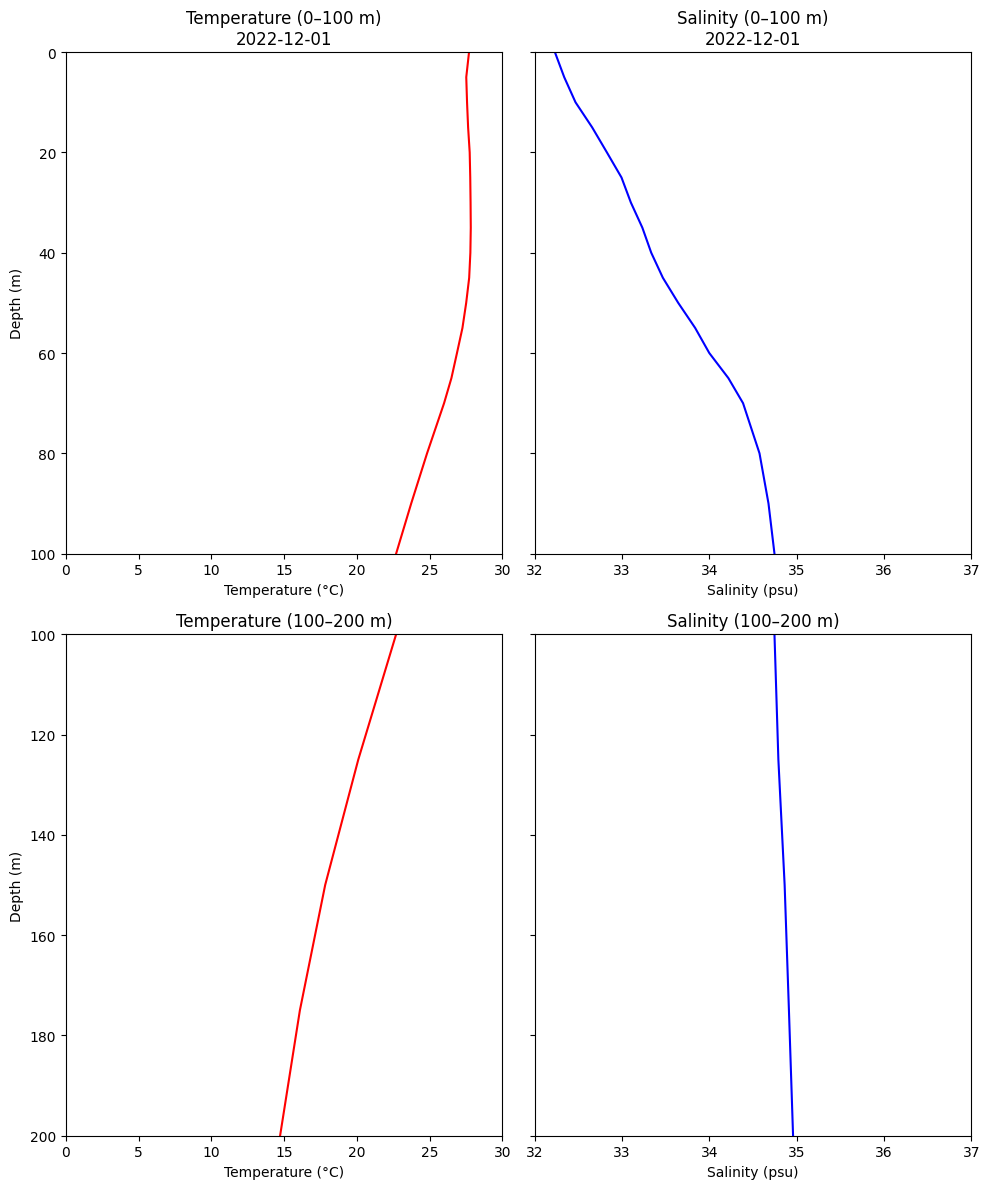

In [ ]:
# Define the actual date you want to use
time = "2022-12-01"  # actual date

# Select region and depth range
salinity_area = ds['so'].sel(
    time=time,
    latitude=slice(10, 20),
    longitude=slice(80, 90),
    depth=slice(0, 200)
)
temperature_area = ds['to'].sel(
    time=time,
    latitude=slice(10, 20),
    longitude=slice(80, 90),
    depth=slice(0, 200)
)

# Average horizontally
salinity_mean_profile = salinity_area.mean(dim=['latitude', 'longitude'])
temperature_mean_profile = temperature_area.mean(dim=['latitude', 'longitude'])

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 12), sharey='row')

# Temperature 0–100 m (top-left)
axs[0, 0].plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')
axs[0, 0].set_ylim(100, 0)
axs[0, 0].set_title(f'Temperature (0–100 m)\n{time}')
axs[0, 0].set_xlabel('Temperature (°C)')
axs[0, 0].set_ylabel('Depth (m)')
axs[0, 0].set_xlim(0, 30)

# Salinity 0–100 m (top-right)
axs[0, 1].plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')
axs[0, 1].set_ylim(100, 0)
axs[0, 1].set_title(f'Salinity (0–100 m)\n{time}')
axs[0, 1].set_xlabel('Salinity (psu)')
axs[0, 1].set_xlim(32, 37)

# Temperature 100–200 m (bottom-left)
axs[1, 0].plot(temperature_mean_profile, temperature_mean_profile['depth'], color='red')
axs[1, 0].set_ylim(200, 100)
axs[1, 0].set_title('Temperature (100–200 m)')
axs[1, 0].set_xlabel('Temperature (°C)')
axs[1, 0].set_ylabel('Depth (m)')
axs[1, 0].set_xlim(0, 30)

# Salinity 100–200 m (bottom-right)
axs[1, 1].plot(salinity_mean_profile, salinity_mean_profile['depth'], color='blue')
axs[1, 1].set_ylim(200, 100)
axs[1, 1].set_title('Salinity (100–200 m)')
axs[1, 1].set_xlabel('Salinity (psu)')
axs[1, 1].set_xlim(32, 37)

# Adjust layout
plt.tight_layout()
plt.show()